In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd
import numpy as np

# Data Collection

In [2]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "1h", 
    days = 1825,
    limit = 1000
)
df = data_collector.collect_data()

In [3]:
df.head()

,timestamp,open,high,low,close,volume
0,2020-10-28 04:00:00,13780.00,13825.00,13713.00,13743.59,2485.421802
1,2020-10-28 05:00:00,13743.59,13771.14,13676.91,13728.45,2668.000123
2,2020-10-28 06:00:00,13728.45,13778.50,13700.59,13709.37,1935.858863
3,2020-10-28 07:00:00,13709.38,13728.68,13506.00,13664.37,5105.065086
4,2020-10-28 08:00:00,13664.36,13688.00,13570.00,13685.61,2693.122892


In [4]:
df.tail()

,timestamp,open,high,low,close,volume
43775,2025-10-26 23:00:00,114681.34,114966.15,114385.13,114559.40,670.95687
43776,2025-10-27 00:00:00,114559.41,115176.47,114362.26,114767.29,1142.27258
43777,2025-10-27 01:00:00,114767.28,115388.96,114710.92,115284.01,725.93495
43778,2025-10-27 02:00:00,115284.01,115445.39,114815.60,114883.39,826.25748
43779,2025-10-27 03:00:00,114883.40,115242.65,114829.48,115018.01,465.98403


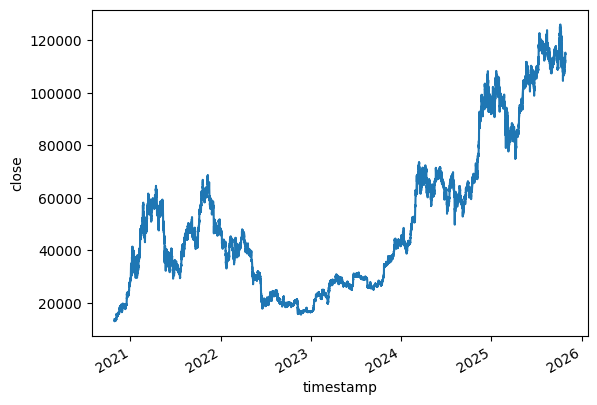

In [5]:
sns.lineplot(x="timestamp", y="close", data=df)
plt.gcf().autofmt_xdate()
plt.show()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43780 entries, 0 to 43779
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  43780 non-null  datetime64[ns]
 1   open       43780 non-null  float64       
 2   high       43780 non-null  float64       
 3   low        43780 non-null  float64       
 4   close      43780 non-null  float64       
 5   volume     43780 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 2.0 MB


In [7]:
df.describe()

,timestamp,open,high,low,close,volume
count,43780,43780.000000,43780.000000,43780.000000,43780.000000,43780.000000
mean,2023-04-28 23:14:16.089538816,51697.591145,51903.721442,51483.248343,51699.904272,3205.567291
min,2020-10-28 04:00:00,13051.680000,13145.360000,12888.000000,13052.060000,0.000000
25%,2022-01-27 23:45:00,27913.632500,27989.537500,27840.877500,27914.447500,800.056455
50%,2023-04-29 01:30:00,43449.885000,43647.145000,43233.835000,43449.880000,1590.646300
75%,2024-07-28 02:15:00,66038.057500,66290.080000,65782.632500,66041.440000,3508.259498
max,2025-10-27 03:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600
std,NaN,29103.140007,29176.963045,29028.580983,29104.148899,4725.012484


# Technical Indicators

### Momentum

In [8]:
##Awesome Oscillator (AO)
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

##KAMA
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

## PPO
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

## PVO
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

## ROC
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

## RSI
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

## STOCHASTIC RSI
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

## STOCHASTIC OSCILLATOR
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

## TSI
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

### Volume

In [9]:
## ADI
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

## CMF
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

##EoM EMV
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()

##FI
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

##MFI
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

##NVI
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

##OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

##VPT
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

## VWAP
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

### Volatility

In [10]:
## ATR
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

## BBANDS
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

## DONCHIAN CHANNEL
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

## KELTNER CHANNEL
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

## Ulcer Index
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

### Trend

In [11]:
## ADX
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

## AROON
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

## CCI
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

## DPO
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

## EMA
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

## KST
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

## MACD
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

## MI
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

## SMA
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

## VI
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

## WMA
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

# Data Cleaning

In [12]:
dataset = df.copy()
data_cleaning = DataCleaning()
dataset = data_cleaning.dropna(dataset)
dataset = data_cleaning.drop_duplicates(dataset)

In [13]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
40,2020-10-29 20:00:00,13492.50,13527.40,13420.00,13479.86,3506.300424,273.669294,13362.453740,0.347336,0.339176,...,87.166747,46.403448,1.192305,45.211143,23.935788,13320.470714,1.083531,0.904076,0.179455,13409.871333
41,2020-10-29 21:00:00,13479.86,13549.91,13423.73,13513.09,1669.508153,268.892706,13397.037448,0.385096,0.301549,...,88.008052,51.491774,11.252198,40.239576,24.037977,13347.200714,1.147604,0.873714,0.273890,13435.553905
42,2020-10-29 22:00:00,13513.09,13520.00,13380.50,13398.97,1911.557074,238.385324,13397.204328,0.342385,0.207071,...,87.825045,45.787965,18.159352,27.628613,24.164978,13366.844286,1.143706,0.840772,0.302934,13442.456476
43,2020-10-29 23:00:00,13398.98,13488.37,13395.21,13455.70,1692.525357,207.872824,13401.420555,0.338753,0.162750,...,87.488363,45.322838,23.592049,21.730789,24.271285,13385.815000,1.131773,0.866125,0.265649,13454.303905
44,2020-10-30 00:00:00,13455.69,13600.00,13285.00,13588.15,4047.926076,176.448176,13411.025569,0.410665,0.187730,...,86.884469,55.007735,29.875186,25.132549,24.640732,13420.860714,1.108572,0.821436,0.287137,13481.281905


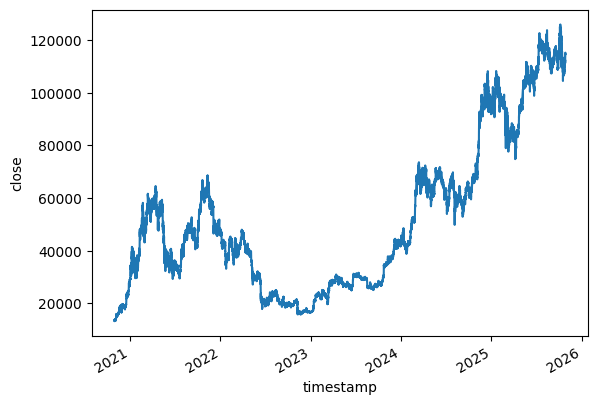

In [14]:
sns.lineplot(x="timestamp", y="close", data=dataset)
plt.gcf().autofmt_xdate()
plt.show()

In [15]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
40,2020-10-29 20:00:00,13492.50,13527.40,13420.00,13479.86,3506.300424,273.669294,13362.453740,0.347336,0.339176,...,87.166747,46.403448,1.192305,45.211143,23.935788,13320.470714,1.083531,0.904076,0.179455,13409.871333
41,2020-10-29 21:00:00,13479.86,13549.91,13423.73,13513.09,1669.508153,268.892706,13397.037448,0.385096,0.301549,...,88.008052,51.491774,11.252198,40.239576,24.037977,13347.200714,1.147604,0.873714,0.273890,13435.553905
42,2020-10-29 22:00:00,13513.09,13520.00,13380.50,13398.97,1911.557074,238.385324,13397.204328,0.342385,0.207071,...,87.825045,45.787965,18.159352,27.628613,24.164978,13366.844286,1.143706,0.840772,0.302934,13442.456476
43,2020-10-29 23:00:00,13398.98,13488.37,13395.21,13455.70,1692.525357,207.872824,13401.420555,0.338753,0.162750,...,87.488363,45.322838,23.592049,21.730789,24.271285,13385.815000,1.131773,0.866125,0.265649,13454.303905
44,2020-10-30 00:00:00,13455.69,13600.00,13285.00,13588.15,4047.926076,176.448176,13411.025569,0.410665,0.187730,...,86.884469,55.007735,29.875186,25.132549,24.640732,13420.860714,1.108572,0.821436,0.287137,13481.281905


# Feature Engineering

### Timestamp Features

In [16]:
dataset["hour"] = dataset['timestamp'].dt.hour
dataset['dayofweek'] = dataset['timestamp'].dt.dayofweek
dataset['quarter'] = dataset['timestamp'].dt.quarter
dataset['month'] = dataset['timestamp'].dt.month
dataset['year'] = dataset['timestamp'].dt.year
dataset['dayofyear'] = dataset['timestamp'].dt.dayofyear
dataset['dayofmonth'] = dataset['timestamp'].dt.day

In [17]:
dataset.tail()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
43775,2025-10-26 23:00:00,114681.34,114966.15,114385.13,114559.40,670.95687,1490.735559,113670.316317,0.579551,0.079307,...,0.733718,0.592260,113790.910286,23,6,4,10,2025,299,26
43776,2025-10-27 00:00:00,114559.41,115176.47,114362.26,114767.29,1142.27258,1630.211353,113808.464366,0.615818,0.092460,...,0.698572,0.552838,113945.601429,0,0,4,10,2025,300,27
43777,2025-10-27 01:00:00,114767.28,115388.96,114710.92,115284.01,725.93495,1847.444912,114042.233300,0.673231,0.119898,...,0.767934,0.507295,114147.377238,1,0,4,10,2025,300,27
43778,2025-10-27 02:00:00,115284.01,115445.39,114815.60,114883.39,826.25748,2112.386941,114134.111972,0.682294,0.103169,...,0.806597,0.376930,114276.709238,2,0,4,10,2025,300,27
43779,2025-10-27 03:00:00,114883.40,115242.65,114829.48,115018.01,465.98403,2115.552618,114252.275892,0.690910,0.089428,...,0.845917,0.345737,114411.530190,3,0,4,10,2025,300,27


In [18]:
dataset = data_cleaning.dropna(dataset)
dataset = data_cleaning.drop_duplicates(dataset)

# Feature Selection

In [19]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [20]:
dataset = dataset.sort_values('timestamp')

In [21]:
X_close = dataset.drop(['timestamp', 'close'], axis=1)
y_close = dataset['close']

### Feature Importance

In [22]:
xgb_close = XGBRegressor(
    device='cuda',
    max_bin=256,
    eval_metric='rmse',
)

In [23]:
tscv = TimeSeriesSplit(n_splits=100)

##### Train the model

In [24]:
## Train the model
def model_training(X, y, model, tscv):
    fold_metrics = []
    n = len(X)
    oof_pred = np.full(shape=n, fill_value=np.nan, dtype=float)
    feature_names = X.columns.tolist()
    fold_id = 0
    gain_accum = pd.Series(0.0, index=feature_names)

    for train_idx, val_idx in tscv.split(X):
        fold_id += 1
        X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False,
        )

        # OOF predictions for this fold’s validation window
        y_val_pred = model.predict(X_test)
        oof_pred[val_idx] = y_val_pred

        # Fold metrics
        rmse = root_mean_squared_error(y_test, y_val_pred)
        mae  = mean_absolute_error(y_test, y_val_pred)
        fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae})

        # Gain importances for this fold (reindexed to all features, missing -> 0)
        gain_dict = model.get_booster().get_score(importance_type="gain")
        gain_fold = pd.Series(gain_dict, dtype=float)

        # xgboost keys are the raw feature names; ensure alignment
        gain_fold.index = [k for k in gain_fold.index]  # no-op but explicit
        gain_fold = gain_fold.reindex(feature_names).fillna(0.0)
        gain_accum += gain_fold

    return fold_metrics, oof_pred, gain_accum


### Get most value variables

In [25]:
features_by_target = {}
fold_metrics, oof_pred, gain_accum = model_training(X_close, y_close, xgb_close, tscv)
importance_df = (
    gain_accum.div(100)             # average gain across folds
    .sort_values(ascending=False)
    .rename("avg_gain")
    .reset_index()
    .rename(columns={"index": "feature"})
)
importance_df["gain_pct"] = (importance_df["avg_gain"] / importance_df["avg_gain"].sum()) * 100
features_by_target["close"] = importance_df[importance_df["gain_pct"] > 0.5]["feature"].tolist()

c:\Users\DG\Desktop\trading-bot-project\data_analysis_trading_bot\venv\Lib\site-packages\xgboost\core.py:729: UserWarning: [21:56:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [26]:
features_by_target

{'close': ['high',
  'low',
  'DONCHIAN_HIGH',
  'VWAP',
  'DONCHIAN_LOW',
  'WMA',
  'SMA',
  'ADI',
  'DONCHIAN_MIDDLE',
  'KAMA',
  'BBANDS_HIGH',
  'EMA',
  'BBANDS_LOWER',
  'BBANDS_MIDDLE']}

In [27]:
all_features = features_by_target["close"] + ["close"]

### Save Selected Features

In [28]:
import os
import json
from datetime import datetime
model_folder = "saved_models"
os.makedirs(model_folder, exist_ok=True)

In [29]:
with open('feature_selection/features_by_target_1h_lstm.json', 'w') as f:
    json.dump(features_by_target, f, indent=4)

# Scale Data

In [30]:
from sklearn.preprocessing import MinMaxScaler

In [34]:
dataset.drop(['timestamp'], axis=1, inplace=True)

In [41]:
dataset.head()

,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
40,13492.50,13527.40,13420.00,13479.86,3506.300424,273.669294,13362.453740,0.347336,0.339176,0.008160,...,0.904076,0.179455,13409.871333,20,3,4,10,2020,303,29
41,13479.86,13549.91,13423.73,13513.09,1669.508153,268.892706,13397.037448,0.385096,0.301549,0.083547,...,0.873714,0.273890,13435.553905,21,3,4,10,2020,303,29
42,13513.09,13520.00,13380.50,13398.97,1911.557074,238.385324,13397.204328,0.342385,0.207071,0.135315,...,0.840772,0.302934,13442.456476,22,3,4,10,2020,303,29
43,13398.98,13488.37,13395.21,13455.70,1692.525357,207.872824,13401.420555,0.338753,0.162750,0.176002,...,0.866125,0.265649,13454.303905,23,3,4,10,2020,303,29
44,13455.69,13600.00,13285.00,13588.15,4047.926076,176.448176,13411.025569,0.410665,0.187730,0.222935,...,0.821436,0.287137,13481.281905,0,4,4,10,2020,304,30


In [35]:
scaler = MinMaxScaler(feature_range= (0, 1))

In [45]:
scaled_data = scaler.fit_transform(dataset[all_features])

In [46]:
scaled_data

array([[2.35685981e-03, 2.71986933e-03, 0.00000000e+00, ...,
        7.36108219e-06, 0.00000000e+00, 2.64372092e-03],
       [2.55617199e-03, 2.75313200e-03, 0.00000000e+00, ...,
        0.00000000e+00, 1.02667846e-04, 2.93823581e-03],
       [2.29133738e-03, 2.36762396e-03, 0.00000000e+00, ...,
        7.34479287e-05, 1.74629488e-04, 1.92679918e-03],
       ...,
       [9.04278181e-01, 9.05992220e-01, 9.04645142e-01, ...,
        8.88331464e-01, 8.97615956e-01, 9.04925932e-01],
       [9.04777834e-01, 9.06925715e-01, 9.04645142e-01, ...,
        8.90510231e-01, 8.99071885e-01, 9.01375268e-01],
       [9.02982696e-01, 9.07049491e-01, 9.04645142e-01, ...,
        8.92927663e-01, 9.00548701e-01, 9.02568395e-01]],
      shape=(43712, 15))

# Splitting the data

In [50]:
train_size = int(len(dataset)*.80)
test_size = len(dataset) - train_size

In [51]:
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size-60:]

In [52]:
train_data.shape, test_data.shape

((34969, 15), (8803, 15))

# Creating training set

In [58]:
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i])
    y_train.append(train_data[i, 3])  # Assuming 'close' is the 4th column in all_features

In [59]:
x_train, y_train = np.array(x_train), np.array(y_train)

In [60]:
x_train.shape , y_train.shape

((34909, 60, 15), (34909,))

# LSTM Models

In [62]:

import keras
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

In [65]:
model = Sequential([
    LSTM(50, return_sequences= True, input_shape= (x_train.shape[1], x_train.shape[2])),
    LSTM(64, return_sequences= False),
    Dense(32),
    Dense(16),
    Dense(1)
])

model.compile(optimizer= 'adam', loss= 'mse' , metrics=['mean_absolute_error'])

In [66]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        13,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,265 (176.82 KB)

 Trainable params: 45,265 (176.82 KB)

 Non-trainable params: 0 (0.00 B)

### Model training

In [67]:
from keras.callbacks import EarlyStopping

In [68]:
# Fitting the LSTM to the Training set
callbacks = [EarlyStopping(monitor= 'loss', patience= 10 , restore_best_weights= True)]
history = model.fit(x_train, y_train, epochs= 100, batch_size= 32 , callbacks= callbacks )

Epoch 1/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - loss: 1.7275e-04 - mean_absolute_error: 0.0038
Epoch 2/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - loss: 7.4705e-06 - mean_absolute_error: 0.0019
Epoch 3/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 8.7078e-06 - mean_absolute_error: 0.0021
Epoch 4/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - loss: 9.4014e-06 - mean_absolute_error: 0.0021
Epoch 5/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - loss: 8.8916e-06 - mean_absolute_error: 0.0022
Epoch 6/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - loss: 7.8563e-06 - mean_absolute_error: 0.0020
Epoch 7/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - loss: 6.8352e-06 - mean_absolute_error: 0.0019
Epoch 8/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - loss: 5.1954e-06 - mean_absolute_error: 0.0016
Epoch 9/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 5.6293e-06 - mean_absolute_error: 0.0017
Epoch 10/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 23

# Model Evaluation

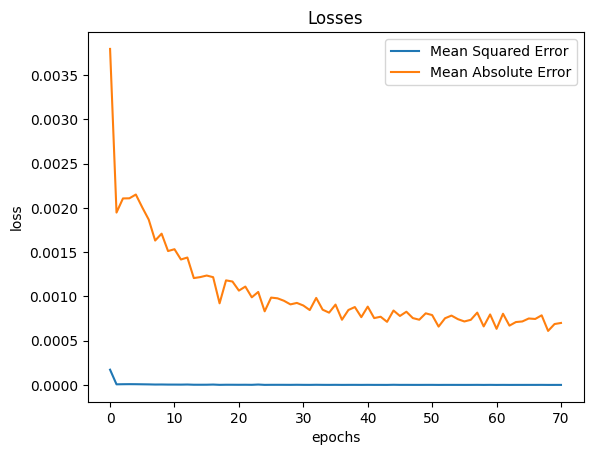

In [69]:
plt.plot(history.history["loss"])
plt.plot(history.history["mean_absolute_error"])
plt.legend(['Mean Squared Error','Mean Absolute Error'])
plt.title("Losses")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

# Prediction

In [71]:
x_test = []
y_test = []

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i])
    y_test.append(test_data[i, 3])



In [73]:
x_test = np.array(x_test)

In [77]:
y_test = np.array(y_test)

In [80]:
x_test.shape , y_test.shape


((8743, 60, 15), (8743,))

In [ ]:
#inverse y_test scaling
predictions = model.predict(x_test)

274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


' predictions = scaler.inverse_transform(predictions)\npredictions.shape '

In [84]:
pred_temp = np.zeros((predictions.shape[0], 15))
pred_temp[:,0] = predictions[:,0]  # 0 es la columna Close

predictions_real = scaler.inverse_transform(pred_temp)
predictions_real = predictions_real[:,0]  # nos quedamos solo con Close

In [88]:
y_temp = np.zeros((y_test.shape[0], 15))
y_temp[:,0] = y_test
y_test_real = scaler.inverse_transform(y_temp)[:,0]

In [89]:
RMSE = np.sqrt(np.mean((y_test_real - predictions_real)**2))
print("Test RMSE:", round(RMSE, 2))

Test RMSE: 1836.87


In [90]:
train = dataset.iloc[:train_size]
test = dataset.iloc[train_size:]

test = test.copy()  # para evitar el famoso Warning de pandas
test['Predictions'] = predictions_real

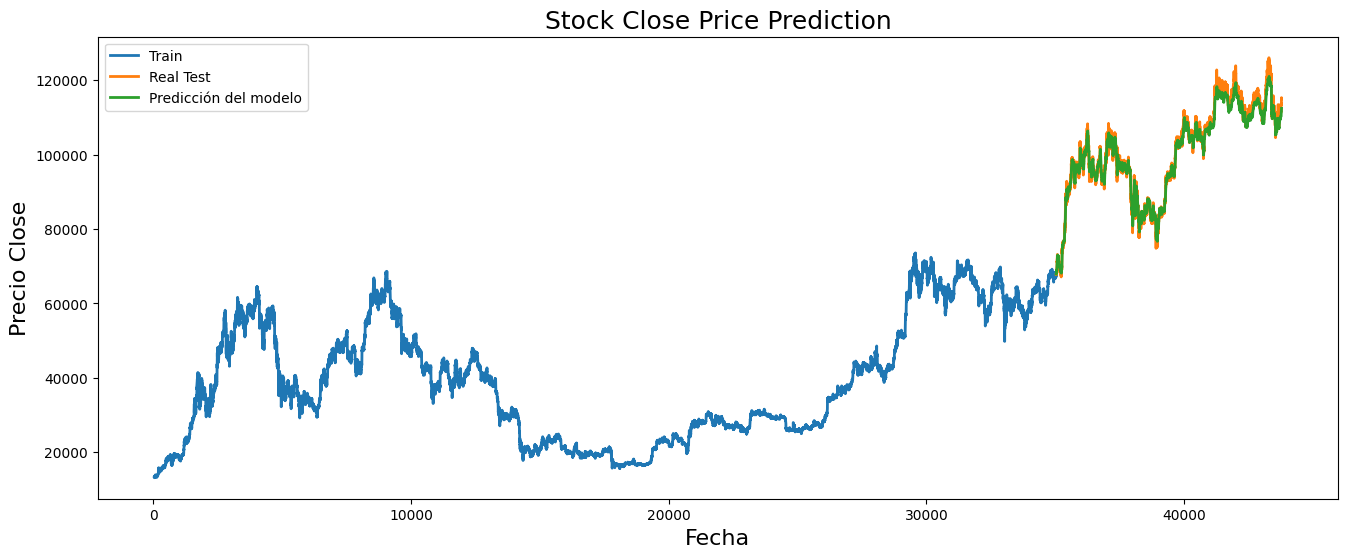

In [92]:
plt.figure(figsize=(16,6))
plt.title('Stock Close Price Prediction', fontsize=18)
plt.xlabel('Fecha', fontsize=16)
plt.ylabel('Precio Close', fontsize=16)

plt.plot(train.index, train['close'], linewidth=2)
plt.plot(test.index, test['close'], linewidth=2)
plt.plot(test.index, test['Predictions'], linewidth=2)

plt.legend(['Train', 'Real Test', 'Predicción del modelo'])
plt.show()